تعداد 6 تصویر جهت پردازش یافت شد.

  مرحله: ۱. تصاویر اصلی


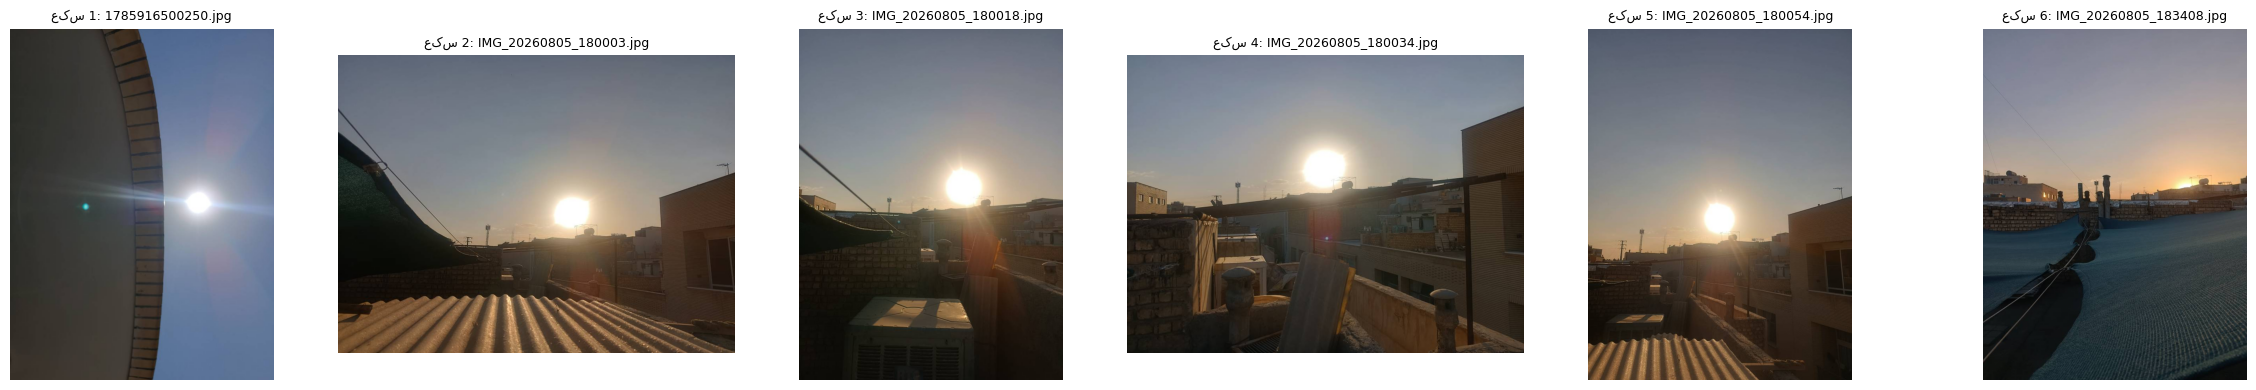

  مرحله: ۲. تصویر خاکستری (Value/Brightness)


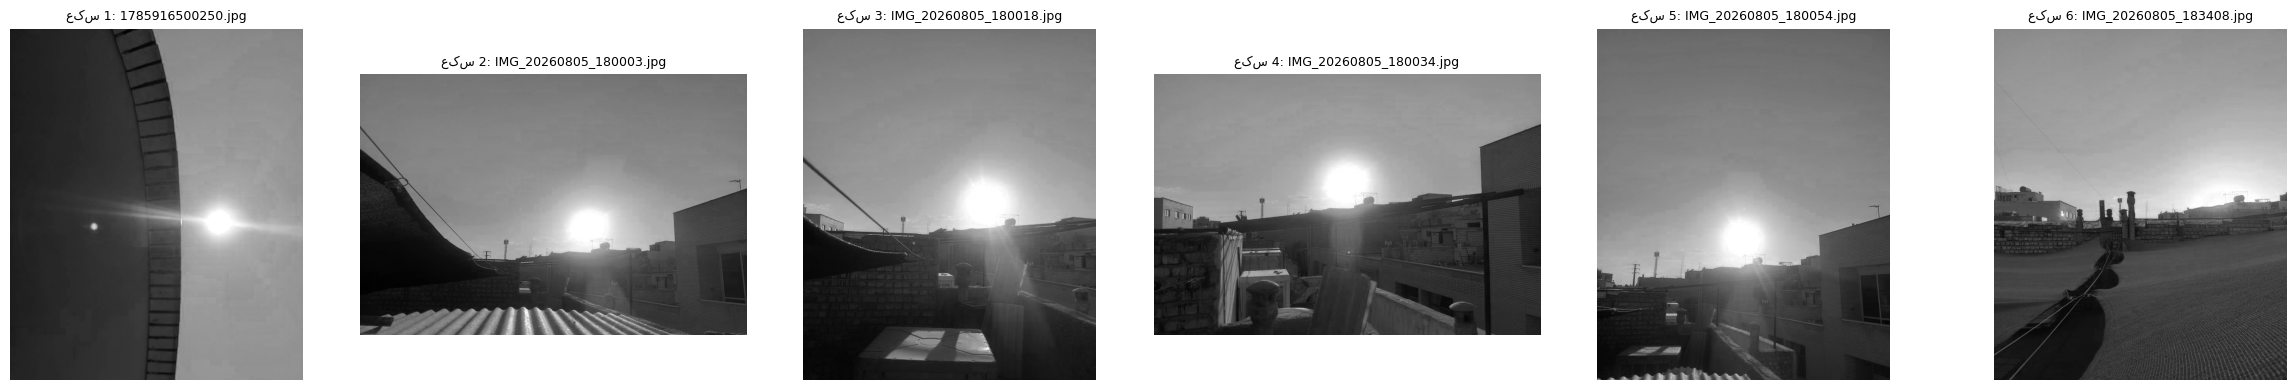

  مرحله: ۳. تصویر Threshold / ماسک نهایی


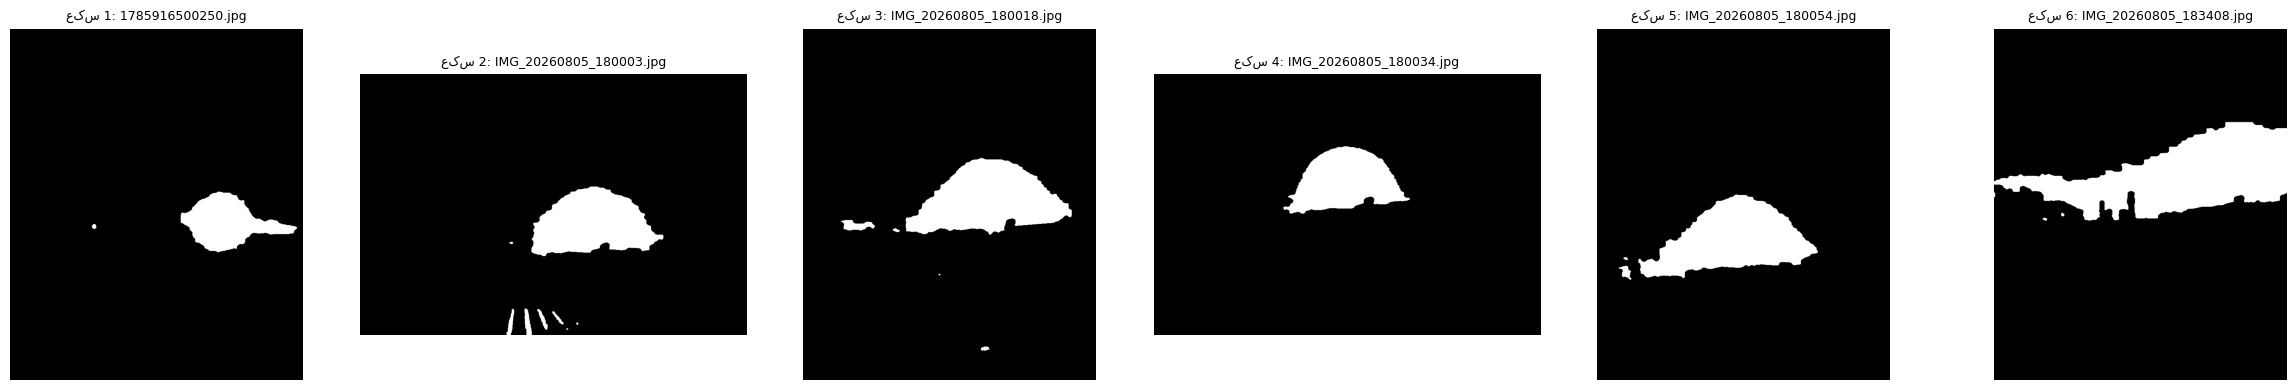

  مرحله: ۴. کانتور انتخاب‌شده


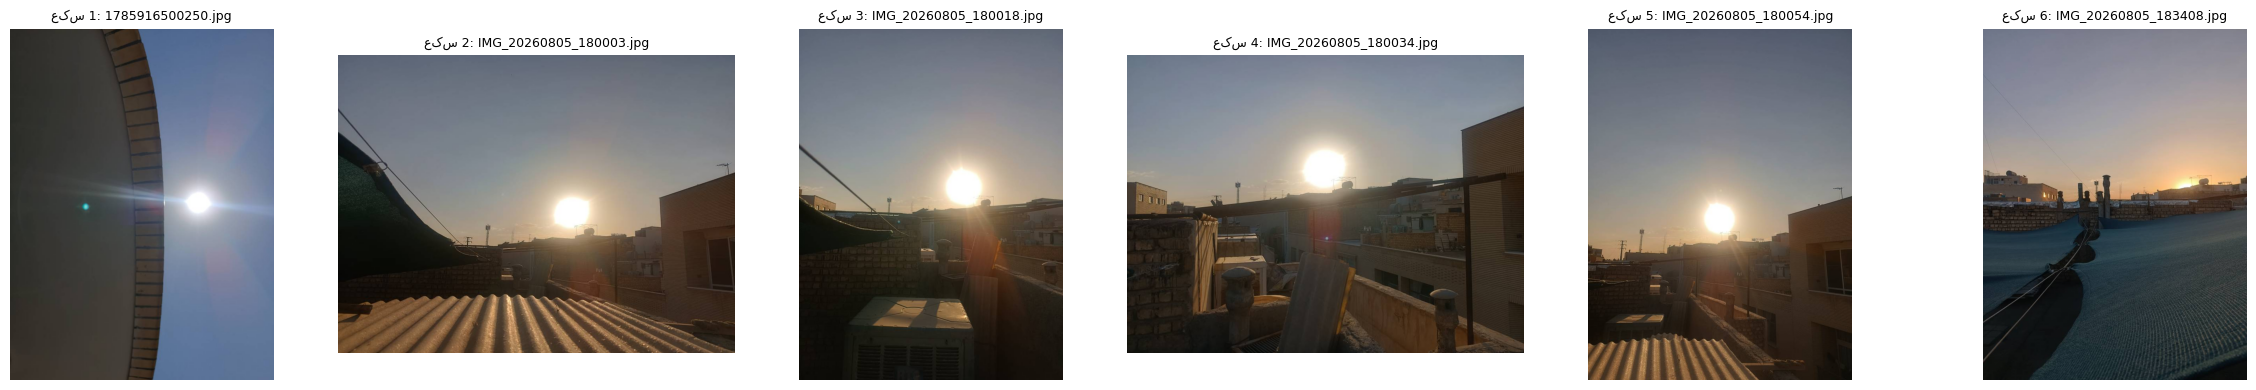

  مرحله: ۵. محدوده ROI پردازش‌شده


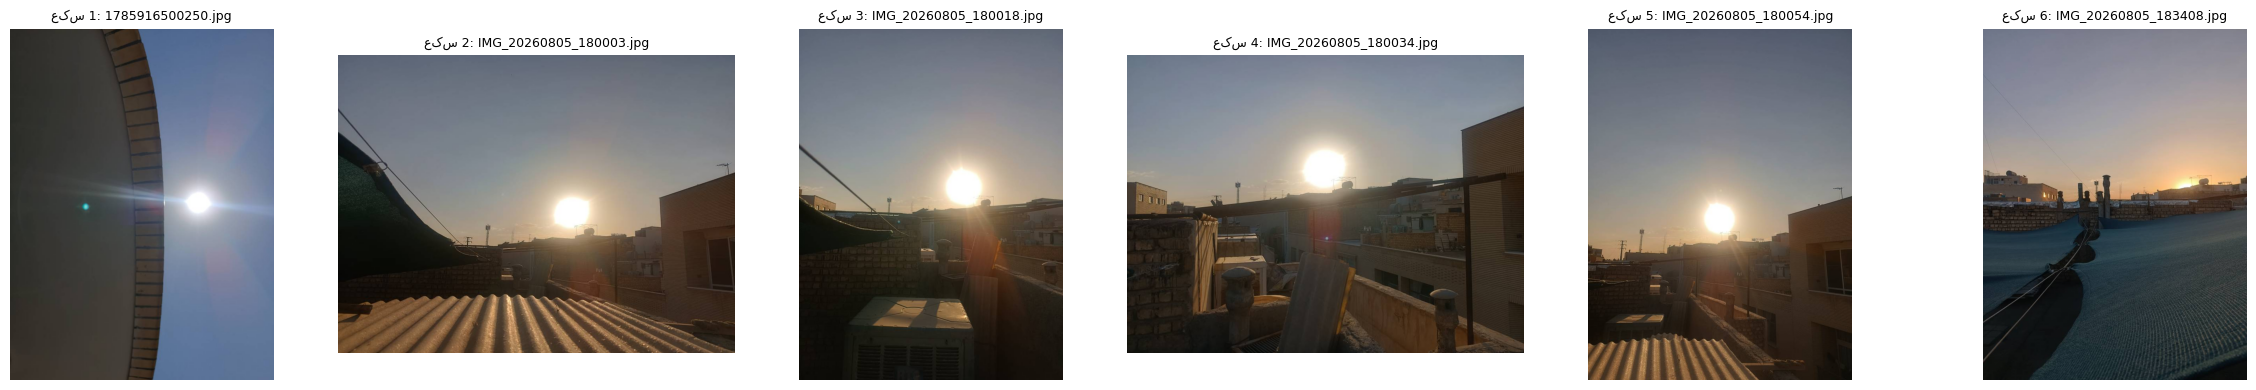

  مرحله: ۶. نتیجه نهایی شناسایی


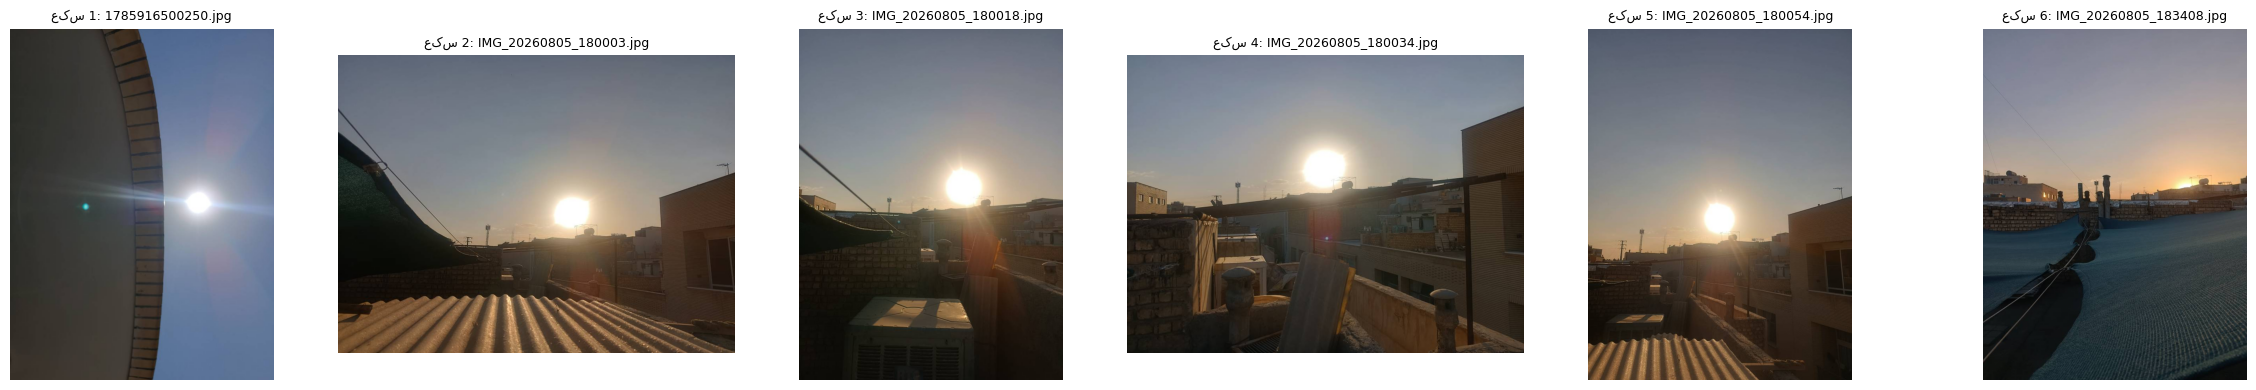

In [15]:
%matplotlib inline
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

# ==========================================================
# Detection Parameters
# ==========================================================

MIN_SUN_AREA_RATIO = 0.0002
MAX_SUN_AREA_RATIO = 0.10

MIN_CIRCULARITY = 0.65
MIN_SOLIDITY = 0.90

MIN_ASPECT_RATIO = 0.60
MAX_ASPECT_RATIO = 1.40

MIN_VALUE_AFTER_OTSU = 180

LOCAL_CONTRAST_LIMIT = 20

TRACKING_WINDOW = 200

# ==========================================================
# ROI Helper
# ==========================================================

def crop_roi(frame, center, window):
    h, w = frame.shape[:2]
    cx, cy = center
    half = window // 2

    x1 = max(0, cx - half)
    y1 = max(0, cy - half)

    x2 = min(w, cx + half)
    y2 = min(h, cy + half)

    roi = frame[y1:y2, x1:x2]
    return roi, x1, y1

# ==========================================================
# Sun Detection (کامل و بدون تغییر منطق)
# ==========================================================

def detect_sun_robust(frame, offset_x=0, offset_y=0):
    if frame is None or frame.size == 0:
        return None, None, None, None

    h, w = frame.shape[:2]

    if offset_x == 0 and offset_y == 0:
        sky_limit = int(h * 0.90)
        frame = frame[:sky_limit]
        h, w = frame.shape[:2]

    total_pixels = h * w

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    value = hsv[:, :, 2]
    blur = cv2.GaussianBlur(value, (9, 9), 0)

    # ----------------------------
    # OTSU & Adaptive Threshold
    # ----------------------------
    _, otsu = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    adaptive = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        61,
        -4
    )

    bright = cv2.inRange(
        value,
        MIN_VALUE_AFTER_OTSU,
        255
    )

    # ----------------------------
    # Final Mask
    # ----------------------------
    mask = cv2.bitwise_or(otsu, adaptive)
    mask = cv2.bitwise_and(mask, bright)

    kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel2)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    best = None
    best_score = -1
    best_contour = None

    # -------------------------------------------------
    # Candidate Selection
    # -------------------------------------------------
    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area < total_pixels * MIN_SUN_AREA_RATIO:
            continue

        if area > total_pixels * MAX_SUN_AREA_RATIO:
            continue

        perimeter = cv2.arcLength(cnt, True)
        if perimeter <= 0:
            continue

        circularity = (4.0 * np.pi * area) / (perimeter * perimeter)
        if circularity < MIN_CIRCULARITY:
            continue

        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        if hull_area <= 0:
            continue

        solidity = area / hull_area
        if solidity < MIN_SOLIDITY:
            continue

        x, y, bw, bh = cv2.boundingRect(cnt)
        if bh == 0:
            continue

        aspect_ratio = bw / float(bh)
        if aspect_ratio < MIN_ASPECT_RATIO or aspect_ratio > MAX_ASPECT_RATIO:
            continue

        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue

        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        object_mask = np.zeros_like(mask)
        cv2.drawContours(object_mask, [cnt], -1, 255, -1)

        mean_value = cv2.mean(value, mask=object_mask)[0]

        # ---------------------------------
        # Local Contrast
        # ---------------------------------
        ring_mask = cv2.dilate(
            object_mask,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
        )
        ring_mask = cv2.subtract(ring_mask, object_mask)

        background_value = cv2.mean(value, mask=ring_mask)[0]
        local_contrast = mean_value - background_value

        if local_contrast < LOCAL_CONTRAST_LIMIT:
            continue

        mean_bgr = cv2.mean(frame, mask=object_mask)[:3]
        (center_tmp, radius) = cv2.minEnclosingCircle(cnt)
        radius = int(radius)

        score = (
            mean_value * 1.8 +
            local_contrast * 8.0 +
            circularity * 250 +
            solidity * 250 +
            np.sqrt(area)
        )

        if score > best_score:
            best_score = score
            best_contour = cnt
            best = {
                "center": (cx + offset_x, cy + offset_y),
                "radius_est": radius,
                "pixel_count": int(area),
                "mean_bgr": mean_bgr,
                "mean_value": mean_value,
                "local_contrast": local_contrast,
                "circularity": circularity,
                "solidity": solidity,
                "score": score
            }

    return best, value, mask, best_contour


# ==========================================================
# Jupyter Folder Pipeline
# ==========================================================

def process_image_folder(folder_path, valid_extensions=('*.jpg', '*.jpeg', '*.png', '*.bmp')):
    image_paths = []
    for ext in valid_extensions:
        image_paths.extend(glob.glob(os.path.join(folder_path, ext)))

    image_paths = sorted(image_paths)

    if not image_paths:
        print(f"هیچ تصاویری در مسیر '{folder_path}' یافت نشد.")
        return

    print(f"تعداد {len(image_paths)} تصویر جهت پردازش یافت شد.\n")

    list_original = []
    list_value = []
    list_threshold = []
    list_contour = []
    list_roi = []
    list_final = []

    last_center = None

    for idx, path in enumerate(image_paths):
        frame = cv2.imread(path)
        if frame is None:
            continue

        h, w = frame.shape[:2]
        original_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        list_original.append((os.path.basename(path), original_rgb))

        if last_center is not None:
            roi, ox, oy = crop_roi(frame, last_center, TRACKING_WINDOW)
            sun, val_img, mask_img, cnt = detect_sun_robust(roi, ox, oy)
        else:
            sun, val_img, mask_img, cnt = detect_sun_robust(frame)
            ox, oy = 0, 0

        if sun is None and last_center is not None:
            sun, val_img, mask_img, cnt = detect_sun_robust(frame)
            ox, oy = 0, 0

        # ۱. تصویر خاکستری (Value)
        list_value.append(val_img if val_img is not None else np.zeros((h, w), dtype=np.uint8))

        # ۲. تصویر Threshold / Mask
        list_threshold.append(mask_img if mask_img is not None else np.zeros((h, w), dtype=np.uint8))

        # ۳. کانتور انتخاب‌شده
        contour_img = frame.copy()
        if cnt is not None:
            cv2.drawContours(contour_img, [cnt], -1, (0, 255, 0), 2)
        list_contour.append(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))

        # ۴. تصویر ROI
        roi_display = frame.copy()
        if last_center is not None:
            half = TRACKING_WINDOW // 2
            rx1, ry1 = max(0, last_center[0] - half), max(0, last_center[1] - half)
            rx2, ry2 = min(w, last_center[0] + half), min(h, last_center[1] + half)
            cv2.rectangle(roi_display, (rx1, ry1), (rx2, ry2), (255, 0, 0), 2)
        list_roi.append(cv2.cvtColor(roi_display, cv2.COLOR_BGR2RGB))

        # ۵. نتیجه نهایی
        final_img = frame.copy()
        if sun is not None:
            last_center = sun["center"]
            cx, cy = sun["center"]
            radius = sun["radius_est"]

            cv2.circle(final_img, (cx, cy), radius, (0, 255, 255), 2)
            cv2.circle(final_img, (cx, cy), 3, (0, 0, 255), -1)
            cv2.putText(final_img, f"Sun ({cx},{cy})", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 255), 2)
            cv2.putText(final_img, f"Score : {sun['score']:.1f}", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.60, (255, 255, 0), 2)
            cv2.putText(final_img, f"Contrast : {sun['local_contrast']:.1f}", (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.60, (255, 255, 255), 2)
        else:
            last_center = None

        list_final.append(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))

    def display_stage(stage_title, images, is_cmap_gray=False):
        print("==================================================")
        print(f"  مرحله: {stage_title}")
        print("==================================================")
        n = len(images)
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
        if n == 1:
            axes = [axes]

        for i, img in enumerate(images):
            if is_cmap_gray:
                axes[i].imshow(img, cmap='gray')
            else:
                axes[i].imshow(img)
            axes[i].set_title(f"عکس {i+1}: {list_original[i][0]}", fontsize=9)
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()

    display_stage("۱. تصاویر اصلی", [img for _, img in list_original])
    display_stage("۲. تصویر خاکستری (Value/Brightness)", list_value, is_cmap_gray=True)
    display_stage("۳. تصویر Threshold / ماسک نهایی", list_threshold, is_cmap_gray=True)
    display_stage("۴. کانتور انتخاب‌شده", list_contour)
    display_stage("۵. محدوده ROI پردازش‌شده", list_roi)
    display_stage("۶. نتیجه نهایی شناسایی", list_final)


# ==========================================================
# فراخوانی تابع (بدون فاصله اضافی در ابتدای خط)
# ==========================================================
process_image_folder("C:/Users/win/Desktop/SunTrackerSplit/Images")